#  Problem Statement & Objective

This project focuses on predicting the **daily audience count** for each cinema theatre. The data comes from two sources:

* **BookNow** (online advance bookings)
* **CinePOS** (on-site POS ticket sales)

Multiple datasets are provided, including theatre info, booking logs, visits, calendar details, and a mapping between BookNow and CinePOS theatres.

The goal is to build a model that learns from **past booking trends, theatre characteristics, calendar effects (weekends/holidays), and visit patterns** to forecast the `audience_count` for each theatre on a future `show_date`.

This is a **time-series forecasting + regression** problem at a theatre–day level. The final submission uses:
**ID = book_theater_id + show_date**

---


# 1. Imports

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import FileLink

from scipy import signal #periodogram
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf, ccf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split,KFold,TimeSeriesSplit,RandomizedSearchCV)
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import Ridge, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Show all columns when displaying DataFrames
pd.set_option('display.max_columns', None)

print("Libraries import done.")

Libraries import done.


In [2]:
try:
    booknow_booking = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")
    cinePOS_booking = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv")
    booknow_theaters = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv")
    cinePOS_theaters = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv")
    booknow_visits = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")
    date_info = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv")
    movie_theater_id_relation = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv")
    test = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")
    
    print("All data files loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading data: {e}")

All data files loaded successfully.


In [3]:
dfs = {
    "booknow_booking": booknow_booking,
    "cinePOS_booking": cinePOS_booking,
    "booknow_theaters": booknow_theaters,
    "cinePOS_theaters": cinePOS_theaters,
    "booknow_visits": booknow_visits,
    "date_info": date_info,
    "movie_theater_id_relation": movie_theater_id_relation,
    "test": test
}

for name, df in dfs.items():
    print(f"{name:<24} | {', '.join(df.columns)}| {df.shape}")

booknow_booking          | book_theater_id, show_datetime, booking_datetime, tickets_booked| (68336, 4)
cinePOS_booking          | cine_theater_id, show_datetime, booking_datetime, tickets_sold| (1641966, 4)
booknow_theaters         | book_theater_id, theater_type, theater_area, latitude, longitude| (829, 5)
cinePOS_theaters         | cine_theater_id, theater_type, theater_area, latitude, longitude| (4690, 5)
booknow_visits           | book_theater_id, show_date, audience_count| (214046, 3)
date_info                | show_date, day_of_week| (547, 2)
movie_theater_id_relation | book_theater_id, cine_theater_id| (150, 2)
test                     | ID, audience_count| (38062, 2)


# 2. Data Merging & Base Table Creation
The data is currently spread across 7 files. My first step is to combine the key temporal datasets `(booknow_booking, cinePOS_booking, booknow_visits, date_info)` into a single "base" DataFrame.

This will give me one row per theater, per day, containing:
- Total online + POS bookings (our main features).

- The target variable (`audience_count`).

- Calendar features (`day_of_week`).

In [6]:
# 1)Aggregating bookings per theater per day 

# Online bookings
booknow_booking['show_date'] = pd.to_datetime(booknow_booking['show_datetime']).dt.date
booknow_daily = booknow_booking.groupby(['book_theater_id', 'show_date'])['tickets_booked'].sum().reset_index()

# POS bookings
cinePOS_booking['show_date'] = pd.to_datetime(cinePOS_booking['show_datetime']).dt.date
cinePOS_daily = cinePOS_booking.groupby(['cine_theater_id', 'show_date'])['tickets_sold'].sum().reset_index()


#2)Map CinePOS theaters -> BookNow theaters (add book_theater_id col to cine table)
cinePOS_daily_mapped = cinePOS_daily.merge(movie_theater_id_relation, on='cine_theater_id', how='left')
# Re - Aggregate
cinePOS_grouped = cinePOS_daily_mapped.groupby(['book_theater_id', 'show_date'])['tickets_sold'].sum().reset_index()


#3)Combine online & POS sales streams 
data = booknow_daily.merge(
    cinePOS_grouped,
    on=['book_theater_id', 'show_date'],
    how='outer'
).fillna(0) #if one source is missing, it sold 0 tickets

data['total_bookings'] = data['tickets_booked'] + data['tickets_sold']

#4)Add actual audience counts
booknow_visits['show_date'] = pd.to_datetime(booknow_visits['show_date']).dt.date
data = data.merge(booknow_visits, on=['book_theater_id', 'show_date'], how='left')

# 5) Add calendar info (day_of_week) for seasonality
date_info['show_date'] = pd.to_datetime(date_info['show_date']).dt.date
data = data.merge(date_info, on='show_date', how='left')

#Check the final merged table
print("Base temporal data merged and prepared.")
print(data.info())
data.head()

Base temporal data merged and prepared.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32985 entries, 0 to 32984
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   book_theater_id  32985 non-null  object 
 1   show_date        32985 non-null  object 
 2   tickets_booked   32985 non-null  float64
 3   tickets_sold     32985 non-null  float64
 4   total_bookings   32985 non-null  float64
 5   audience_count   27892 non-null  float64
 6   day_of_week      32985 non-null  object 
dtypes: float64(4), object(3)
memory usage: 1.8+ MB
None


,book_theater_id,show_date,tickets_booked,tickets_sold,total_bookings,audience_count,day_of_week
0,book_00004,2023-02-27,12.0,0.0,12.0,12.0,Monday
1,book_00013,2023-01-04,2.0,0.0,2.0,122.0,Wednesday
2,book_00013,2023-01-08,3.0,0.0,3.0,42.0,Sunday
3,book_00013,2023-01-09,25.0,0.0,25.0,114.0,Monday
4,book_00013,2023-01-10,5.0,0.0,5.0,64.0,Tuesday


**Merge Complete**  
The `data` DataFrame is now ready. It has all the time-based data in one place.
Next, I'll create a global time series from `data` for EDA.

# 3) EDA

## 3a) Basic EDA -- target column

### (i) Histogram of Target

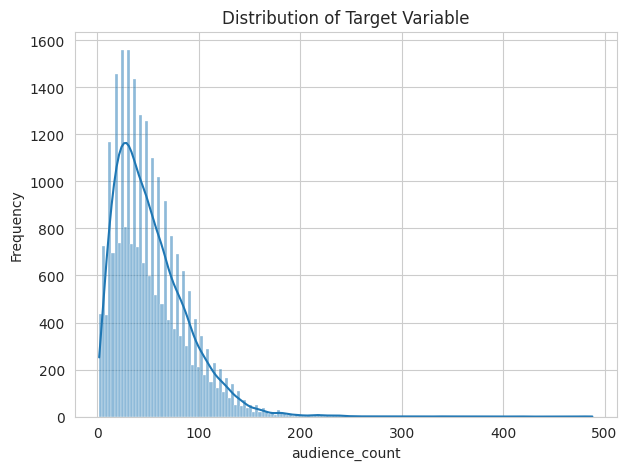

In [11]:
target_col = "audience_count"
plt.figure(figsize=(7,5))
sns.histplot(data[target_col], kde=True)
plt.title("Distribution of Target Variable")
plt.xlabel(target_col)
plt.ylabel("Frequency")
plt.show()

### (ii) Boxplot of Target (Outliers Check)

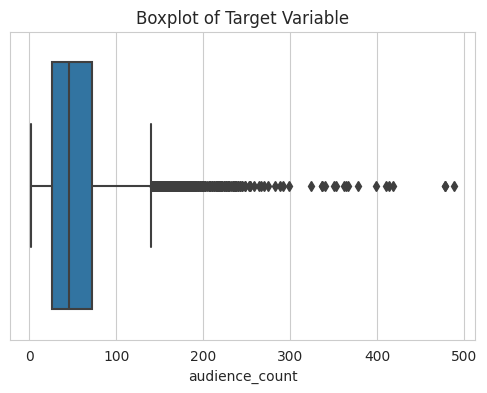

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x=data[target_col])
plt.title("Boxplot of Target Variable")
plt.show()


## 3b) Time series EDA
Creating global time-series for EDA

In [20]:
data['show_date'] = pd.to_datetime(data['show_date'])
global_data = data.groupby('show_date')[['audience_count', 'total_bookings']].sum().reset_index()
global_data = global_data.set_index('show_date').sort_index()

print("Created 'global_data' for site-wide EDA.")
print(global_data.head(2))

Created 'global_data' for site-wide EDA.
            audience_count  total_bookings
show_date                                 
2023-01-01            64.0            23.0
2023-01-02           678.0           187.0


### (i) Trend  
First, I'll plot the moving averages for `audience_count`. This will help me understand the overall long-term trend and smooth out the daily noise.

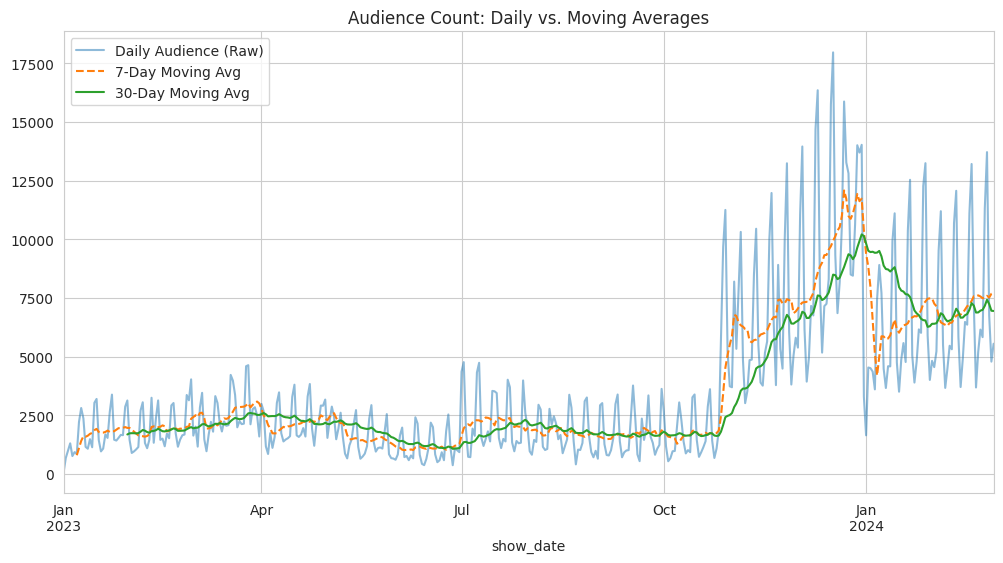

In [6]:
# Plot the raw daily audience (light blue)
ax = global_data['audience_count'].plot(label='Daily Audience (Raw)', alpha=0.5)

# Overlay a 7-day rolling average to see the weekly pattern
global_data['audience_count'].rolling(7).mean().plot(ax=ax, label='7-Day Moving Avg', style='--')

# Overlay a 30-day average to identify the long-term trend
global_data['audience_count'].rolling(30).mean().plot(ax=ax, label='30-Day Moving Avg', style='-')

ax.set_title('Audience Count: Daily vs. Moving Averages')
ax.legend()
plt.show()

**Analysis & Decision: Structural Break**  
This plot is very revealing. It's not a simple, smooth trend. The data was stable and predictable for most of 2023, and then—bam—there's a permanent jump (a "structural break") to a new, higher baseline around October/November.

This is the most important pattern I've found. It means the model needs to be agile and can't rely on a 30-day average, which is too slow to react.

→ Decision: I must use short-term rolling features, like a 7-day rolling average, that can adapt to this new "normal" quickly.

### (ii) Seasonality  
After checking the long-term trend, I'll now check for fixed, repeating cycles (seasonality). This will help me validate the date-based features from my plan, like is_weekend and month.  
I'll use boxplots to see how the audience count distributes by day of the week and by month

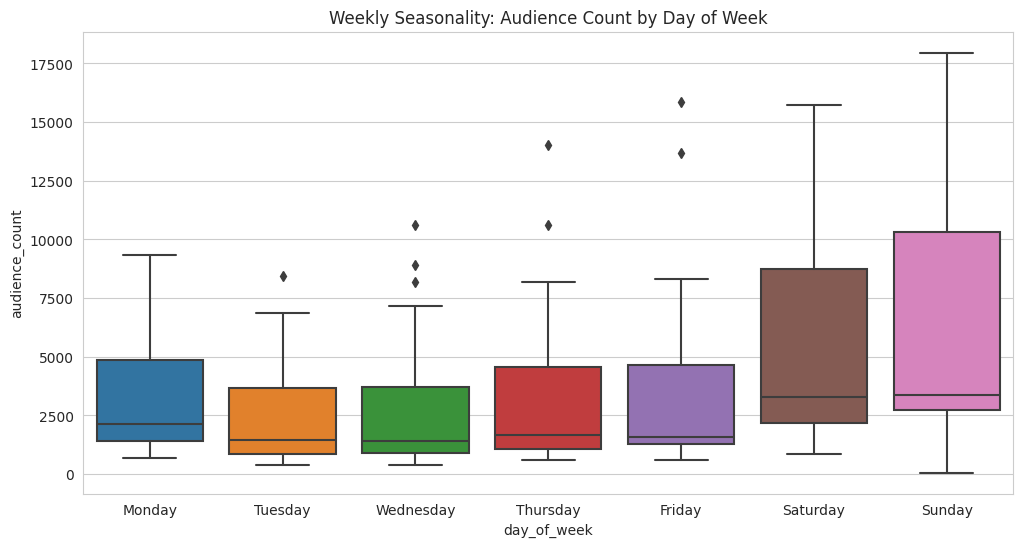

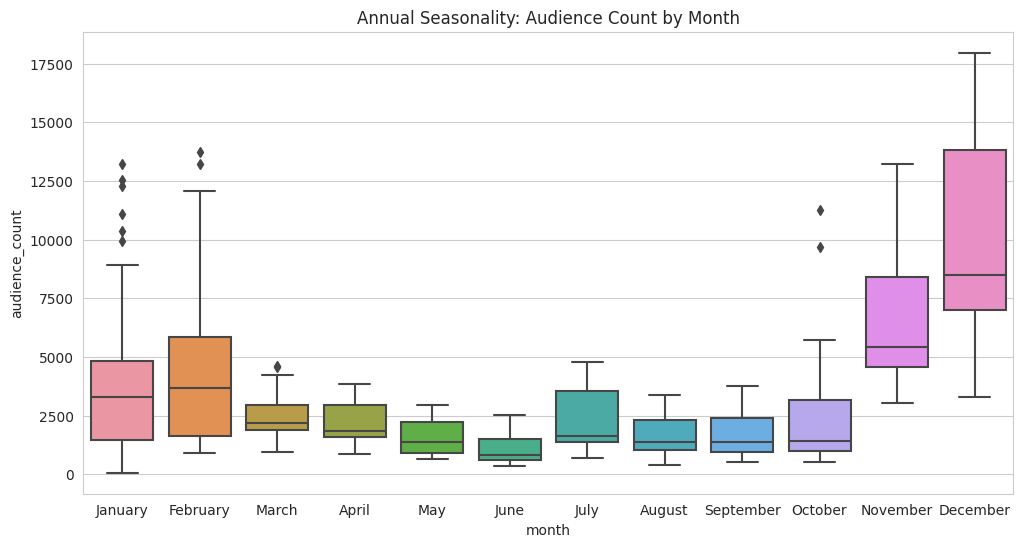

In [7]:
plot_data = global_data.copy()
plot_data['day_of_week'] = plot_data.index.day_name()
plot_data['month'] = plot_data.index.month_name()

week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_data, x='day_of_week', y='audience_count', order=week_order)
plt.title('Weekly Seasonality: Audience Count by Day of Week')
plt.show()

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
               
plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_data, x='month', y='audience_count', order=month_order)
plt.title('Annual Seasonality: Audience Count by Month')
plt.show()

**Analysis & Decisions: Seasonality**
These two boxplots give me clear, actionable insights.

1. **Weekly Seasonality**: This is the most obvious pattern. It's not subtle at all. As the plot shows, Saturday and Sunday are completely different from the rest of the week, with much higher and more varied audience counts. Friday is also slightly elevated, acting as a "ramp" to the weekend.

→ **Decision:** The model must know what day it is. This confirms that is_weekend and is_long_weekend are critical categorical features.

2. **Annual Seasonality**: The monthly plot shows a clear "U-shape." There's a distinct slump in the summer (May/June) and an explosion in the holiday season (November and December). A simple 7-day lag feature would never capture this, as the model won't know what time of year it is.

→ **Decision:** I have to include month and quarter as features to give the model this high-level "time of year" context.

### (iii) Periodogram  
The boxplots showed clear weekly and annual patterns. Now, I'll use a periodogram to mathematically confirm the single strongest, most dominant cycle in the data. This plot shows the "power" of different cycle lengths.

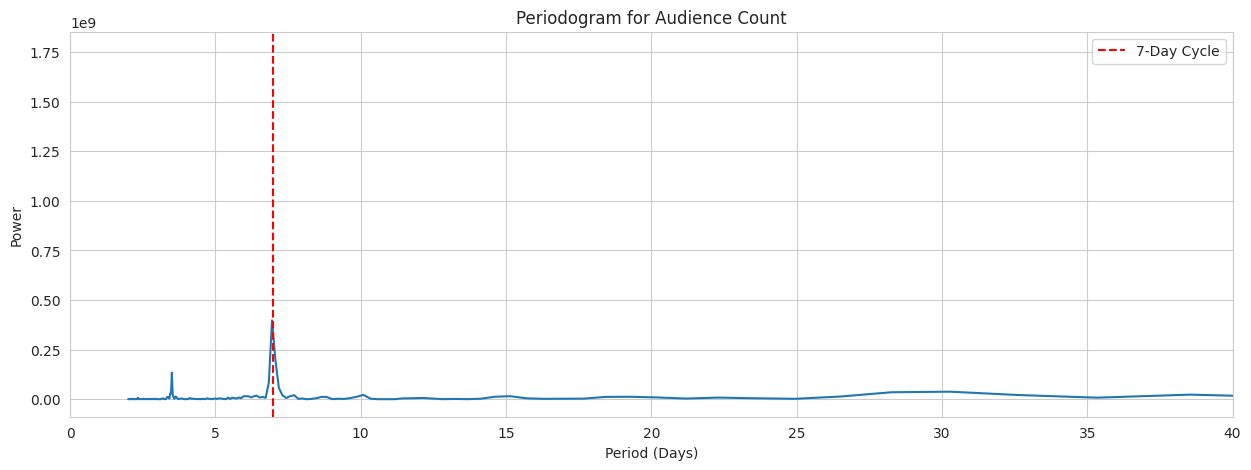

In [8]:
ts_audience = global_data['audience_count'].fillna(0)

frequencies, power = signal.periodogram(ts_audience, fs=1) #fs=1 means 1 sample per day
plt.figure(figsize=(15, 5))

# Plot power vs. period (1/frequency) to see cycle length in days
plt.plot(1/frequencies, power)
plt.title('Periodogram for Audience Count')
plt.xlabel('Period (Days)')
plt.ylabel('Power')
plt.xlim(0, 40) # Focus on cycles between 0 and 40 days

# vertical line to explicitly check for a 7-day cycle
plt.axvline(x=7, color='red', linestyle='--', label='7-Day Cycle')
plt.legend()
plt.show()

**Analysis & Decision: 7-Day Cycle Confirmed**
This just confirms what the boxplot showed, but with math. That one massive spike at Period = 7 means the 7-day (weekly) cycle is the "heartbeat" of this entire dataset. Everything else is just noise in comparison.

This gives me 100% confidence that any feature based on a 7-day cycle is a good bet.

→ **Decision:** This plot encourages me to use weekly features.

### (iv) PACF  
This is the most important part of my time-series EDA. I need to find out which specific past days (lags) have a direct impact on the current day's value. I'll use a Partial Autocorrelation Function **(PACF) plot** for this.

PACF is better than a standard Correlation plot because it removes the effects of shorter, in-between lags. It answers the question: "Does `lag_7` matter, or is it just an echo of `lag_1`?"

I'll check this for both my target (`audience_count`) and my main predictor (`total_bookings`).

--- PACF Analysis for Audience Count ---
Significance Threshold (approx): +/- 0.0953
Significant Lags Found:
  Lag 2: -0.4510
  Lag 4: -0.3419
  Lag 5: -0.6090
  Lag 6: -0.3136
  Lag 7: 0.2899
  Lag 12: -0.1061
  Lag 13: -0.1085
  Lag 20: -0.0981
  Lag 23: 0.0959
  Lag 27: -0.1792


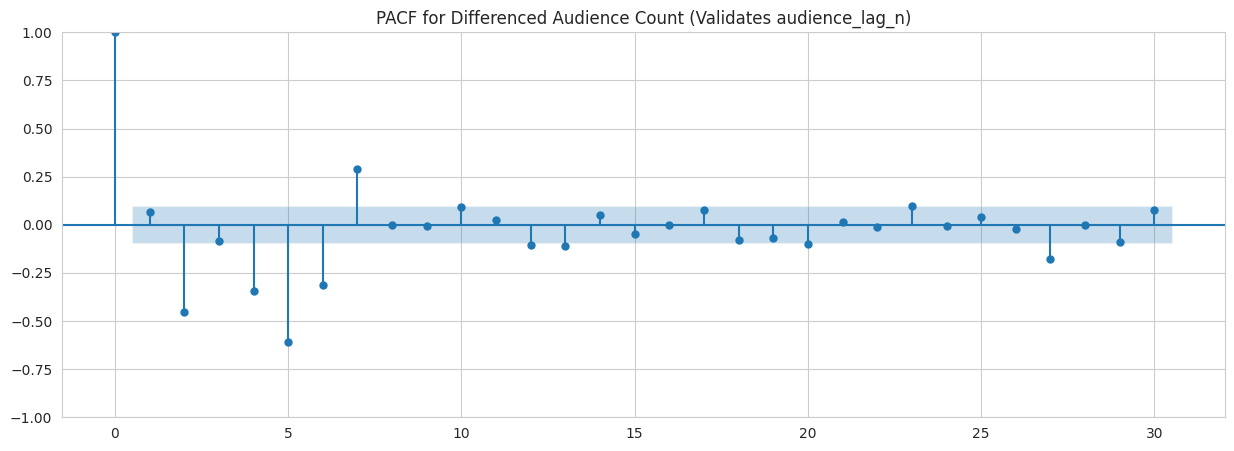


--- PACF Analysis for Total Bookings ---
Significance Threshold (approx): +/- 0.0953
Significant Lags Found:
  Lag 2: -0.3370
  Lag 3: -0.1987
  Lag 4: -0.2873
  Lag 5: -0.5090
  Lag 6: -0.3441
  Lag 7: 0.1340
  Lag 8: 0.1176
  Lag 9: -0.1122
  Lag 14: 0.0981
  Lag 17: 0.0986
  Lag 19: -0.1537
  Lag 20: -0.1455


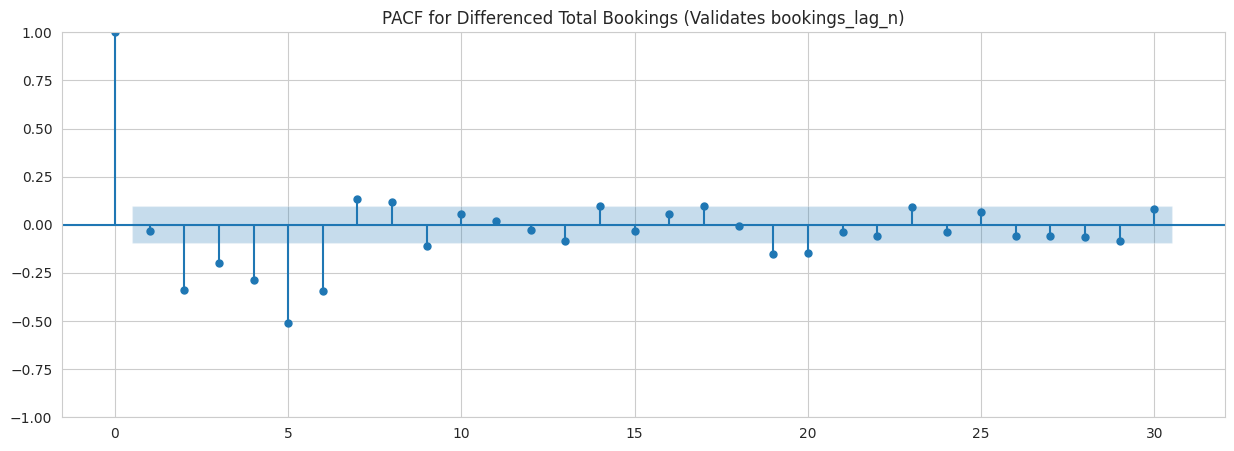

In [10]:
print("--- PACF Analysis for Audience Count ---")

audience_diff = global_data['audience_count'].diff().dropna() #.diff() because PACF works best on stationary data

#PACF values & confidence intervals 
pacf_values, conf_int = pacf(audience_diff, nlags=30, alpha=0.05, method='ywm')

# significance threshold from the confidence interval
significance_threshold = conf_int[1][1] - pacf_values[1] 
print(f"Significance Threshold (approx): +/- {significance_threshold:.4f}")

# printing all significant lags
significant_lags_audience = []
for lag in range(1, len(pacf_values)):
    if abs(pacf_values[lag]) > significance_threshold:
        significant_lags_audience.append((lag, pacf_values[lag]))

if significant_lags_audience:
    print("Significant Lags Found:")
    for lag, value in significant_lags_audience:
        print(f"  Lag {lag}: {value:.4f}")
else:
    print("No significant lags found.")

fig, ax = plt.subplots(figsize=(15, 5))
plot_pacf(audience_diff, lags=30, ax=ax, method='ywm')
ax.set_title('PACF for Differenced Audience Count (Validates audience_lag_n)')
plt.show()


print("\n--- PACF Analysis for Total Bookings ---")
bookings_diff = global_data['total_bookings'].diff().dropna()

pacf_values_book, conf_int_book = pacf(bookings_diff, nlags=30, alpha=0.05, method='ywm')
significance_threshold_book = conf_int_book[1][1] - pacf_values_book[1]
print(f"Significance Threshold (approx): +/- {significance_threshold_book:.4f}")

significant_lags_bookings = []
for lag in range(1, len(pacf_values_book)):
    if abs(pacf_values_book[lag]) > significance_threshold_book:
        significant_lags_bookings.append((lag, pacf_values_book[lag]))

if significant_lags_bookings:
    print("Significant Lags Found:")
    for lag, value in significant_lags_bookings:
        print(f"  Lag {lag}: {value:.4f}")
else:
    print("No significant lags found.")
    
fig, ax = plt.subplots(figsize=(15, 5))
plot_pacf(bookings_diff, lags=30, ax=ax, method='ywm')
ax.set_title('PACF for Differenced Total Bookings (Validates bookings_lag_n)')
plt.show()

**Analysis & Decision: Audience Lags**  
The PACF for `audience_count` is very interesting. It's not just lag 1 or lag 7. I'm seeing strong signals at lags 2, 4, 5, 6, and 7. This suggests that today's audience is affected by a complex "echo" from the past week (e.g., a big Sunday at lag 2 might negatively affect a Tuesday).

→ **Decision:** I'll capture this echo by creating lag features for `audience_count` at these exact significant lags.

The PACF for `total_bookings` (lags 2, 3, 4, 5, 6, 7) shows how bookings relate to past bookings. This is useful, but what I really care about is how bookings relate to my **target**, `audience_count`. The next plot, a Cross-Correlation Function (CCF), will answer this much better.

### (vi) CCF  
This is the "Aha!" moment. Instead of checking how bookings relate to past bookings (PACF), I'll now check how *past bookings* relate to today's audience (CCF).

This plot directly answers: "Which `bookings_lag_n` features will be the best predictors for my model?"

--- CCF Analysis: Audience vs. Bookings ---
Top 10 Most Correlated Lags (0-30):
    Lag  Correlation
0     0     0.895733
7     7     0.608773
14   14     0.488724
21   21     0.441244
28   28     0.429590
8     8     0.156564
1     1     0.150469
29   29     0.128738
22   22     0.100740
15   15     0.080849

Lags with Correlation > 0.2 (my significance rule of thumb):
    Lag  Correlation
0     0     0.895733
7     7     0.608773
14   14     0.488724
21   21     0.441244
28   28     0.429590


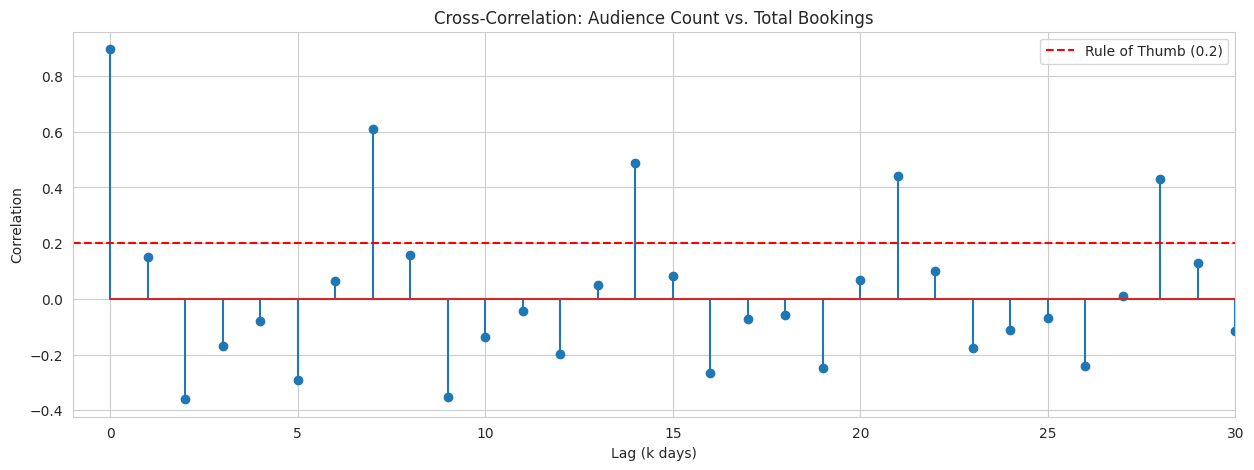

In [11]:
# Align the two differenced (stationary) series
x = bookings_diff
y = audience_diff
aligned_len = min(len(x), len(y))
x_aligned = x.iloc[-aligned_len:]
y_aligned = y.iloc[-aligned_len:]

# Calculate the cross-correlation
ccf_values = ccf(y_aligned, x_aligned, adjusted=True)

# Put values into a DataFrame so we can see the top lags
ccf_df = pd.DataFrame({
    'Lag': range(len(ccf_values)),
    'Correlation': ccf_values
}).iloc[0:31] # Slicing to show lags 0-30

print("--- CCF Analysis: Audience vs. Bookings ---")
print("Top 10 Most Correlated Lags (0-30):")
print(ccf_df.sort_values(by='Correlation', ascending=False).head(10))

print("\nLags with Correlation > 0.2 (my significance rule of thumb):")
print(ccf_df[ccf_df['Correlation'] > 0.2])

# Plot
plt.figure(figsize=(15, 5))
plt.stem(range(len(ccf_values)), ccf_values)
plt.title('Cross-Correlation: Audience Count vs. Total Bookings')
plt.xlabel('Lag (k days)')
plt.ylabel('Correlation')
plt.xlim(-1, 30) # Focus on lags 0-30
plt.axhline(0.2, color='red', linestyle='--', label='Rule of Thumb (0.2)')
plt.legend()
plt.show()

**Analysis & Decision: Booking Lags**
This CCF plot is crystal clear and much more useful than the total_bookings PACF.

1. `Lag 0` has a **0.89 correlation**! This is the jackpot. It proves the single best predictor for today's audience is today's total bookings.

2. The next strongest spikes are all on a 7-day cycle: `Lag 7` **(0.60)**, `Lag 14` **(0.48)**, and `Lag 21` **(0.44)**.

3. `bookings_lag1` (0.15), which I might have assumed was important, is actually very weak.

→ **Decision:** I will trust this CCF plot for all my total_bookings features. The PACF for bookings was not asking the right question.  
My booking-related features will be: `total_bookings`, `bookings_lag7`, `bookings_lag14`, and `bookings_lag21`.
Since booking features won't be available for test set, I opted to not include them for training and validation either.

## 3b) Metadata Analysis
___

### (i) Merging Static Features
My `data` DataFrame now has all the time-based features. I still need to add the static metadata for each theater (type, location, etc.). This data is split between `booknow_theaters` and `cinePOS_theaters`.

My goal here is to create a single, clean "master list" of theater info, `theaters_meta1`, before merging it into the main `data` table.

In [12]:
theaters_meta1 = booknow_theaters.copy()
print(f"Step 1: Base table created from booknow_theaters. Shape: {theaters_meta1.shape}")
print(theaters_meta1.head())

# This adds the 'cine_theater_id' key, needed to join the CinePOS metadata.
theaters_meta1 = theaters_meta1.merge(
    movie_theater_id_relation,
    on='book_theater_id',
    how='left'  
)
print(f"\nStep 2: Added 'cine_theater_id' column. Shape: {theaters_meta1.shape}")
print(theaters_meta1.head())

theaters_meta1 = theaters_meta1.merge(
    cinePOS_theaters,
    on='cine_theater_id',
    how='left',
    suffixes=('_book', '_cine') #'suffixes' to create temporary '_book' and '_cine' columns
)
print(f"\nStep 3: Added CinePOS metadata with suffixes. Shape: {theaters_meta1.shape}")
print(theaters_meta1.filter(like='theater_type').head(2))

Step 1: Base table created from booknow_theaters. Shape: (829, 5)
  book_theater_id theater_type theater_area   latitude  longitude
0      book_00093        Drama     Area_001  22.619233  78.113017
1      book_00078        Drama     Area_001  22.619233  78.113017
2      book_00291        Drama     Area_001  22.619233  78.113017
3      book_00258        Drama     Area_001  22.619233  78.113017
4      book_00212        Drama     Area_002  23.004410  79.934515

Step 2: Added 'cine_theater_id' column. Shape: (829, 6)
  book_theater_id theater_type theater_area   latitude  longitude  \
0      book_00093        Drama     Area_001  22.619233  78.113017   
1      book_00078        Drama     Area_001  22.619233  78.113017   
2      book_00291        Drama     Area_001  22.619233  78.113017   
3      book_00258        Drama     Area_001  22.619233  78.113017   
4      book_00212        Drama     Area_002  23.004410  79.934515   

  cine_theater_id  
0   cinePOS_00237  
1   cinePOS_08924  
2     

### (ii) Consolidating Features
Now I have duplicate columns (e.g., `theater_type_book`, `theater_type_cine`). A simple `fillna` isn't smart enough, as one source might have '0' or 'other' while the other has a real value.

I'll write a function to *prioritize the most specific information*, creating one clean, final column for each attribute.

In [13]:
print("\nStep 4: Consolidating columns with specificity logic...")

#generic data we want to avoid if a better option exists
GENERIC_STRINGS = ['other', 'unknown', 'nan', 'na', 'n/a']
GENERIC_NUMBERS = [0, 0.0]

def get_specific_value(book_val, cine_val):
    """ Compares book/cine values and returns the more specific one. """
    
    # Check if book/cine values are generic
    is_book_generic_num = pd.isnull(book_val) or (book_val in GENERIC_NUMBERS)
    is_cine_generic_num = pd.isnull(cine_val) or (cine_val in GENERIC_NUMBERS)
    is_book_generic_str = pd.isnull(book_val) or (str(book_val).lower() in GENERIC_STRINGS)
    is_cine_generic_str = pd.isnull(cine_val) or (str(cine_val).lower() in GENERIC_STRINGS)
    
    # Case 1: Cine is specific and Book is generic -> Use Cine
    if (not is_cine_generic_str and not is_cine_generic_num) and (is_book_generic_str or is_book_generic_num):
        return cine_val
    
    # Case 2: All other cases (Book -- specific, or both are) -> Default to Book
    return book_val

# Columns to consolidate
meta_cols = ['theater_type', 'theater_area', 'latitude', 'longitude']

for col in meta_cols:
    book_col = f"{col}_book"
    cine_col = f"{col}_cine"
    
    #apply logic row by row
    theaters_meta1[col] = theaters_meta1.apply(
        lambda row: get_specific_value(row[book_col], row[cine_col]),
        axis=1 
    )
    #drop temporary suffixed columns
    theaters_meta1 = theaters_meta1.drop(columns=[book_col, cine_col])

print("Consolidation complete.")
print("--- Final Consolidated Metadata (theaters_meta1) ---")
print(theaters_meta1[['book_theater_id', 'theater_type', 'theater_area', 'latitude', 'longitude']].head())


Step 4: Consolidating columns with specificity logic...
Consolidation complete.
--- Final Consolidated Metadata (theaters_meta1) ---
  book_theater_id theater_type theater_area   latitude  longitude
0      book_00093        Drama     Area_001  22.619233  78.113017
1      book_00078        Drama     Area_001  22.619233  78.113017
2      book_00291        Drama     Area_001  22.619233  78.113017
3      book_00258        Drama     Area_001  22.619233  78.113017
4      book_00212        Drama     Area_002  23.004410  79.934515


### (iii) Final Merge
This `theaters_meta1` table is now my clean, static "master list." I'll merge it into my main temporal data DataFrame. This adds the static theater features (like type, lat/lon) to every single day for that theater, making them ready for analysis

In [14]:
print("Merging clean metadata into main 'data' DataFrame...")

#final clean columns to add
final_meta_cols = ['book_theater_id', 'theater_type', 'theater_area', 'latitude', 'longitude']
theaters_meta_final = theaters_meta1[final_meta_cols].drop_duplicates()

data = data.merge(
    theaters_meta_final,
    on='book_theater_id',
    how='left'
)

#fill any remaining NaNs (for theaters with no metadata at all)
data['theater_type'] = data['theater_type'].fillna('Unknown')
data['theater_area'] = data['theater_area'].fillna('Unknown')
data[['latitude', 'longitude']] = data[['latitude', 'longitude']].fillna(0)

print(f"Merge complete! 'data' now has {data.shape[1]} columns.")
print(f"Columns in 'data' are : {data.columns.tolist()}")

Merging clean metadata into main 'data' DataFrame...
Merge complete! 'data' now has 11 columns.
Columns in 'data' are : ['book_theater_id', 'show_date', 'tickets_booked', 'tickets_sold', 'total_bookings', 'audience_count', 'day_of_week', 'theater_type', 'theater_area', 'latitude', 'longitude']


### (iv) EDA Plots
All features are now in one DataFrame. Before I create the preprocessing pipeline, I need to see if these new static features are actually predictive.

1. **Boxplot:** Does `theater_type` (categorical) affect `audience_count`?

2. **Scatter Plot:** Does `latitude`/`longitude` (spatial) affect the *average* `audience_count`?

--- Plot 1: Audience Count by Theater Type ---


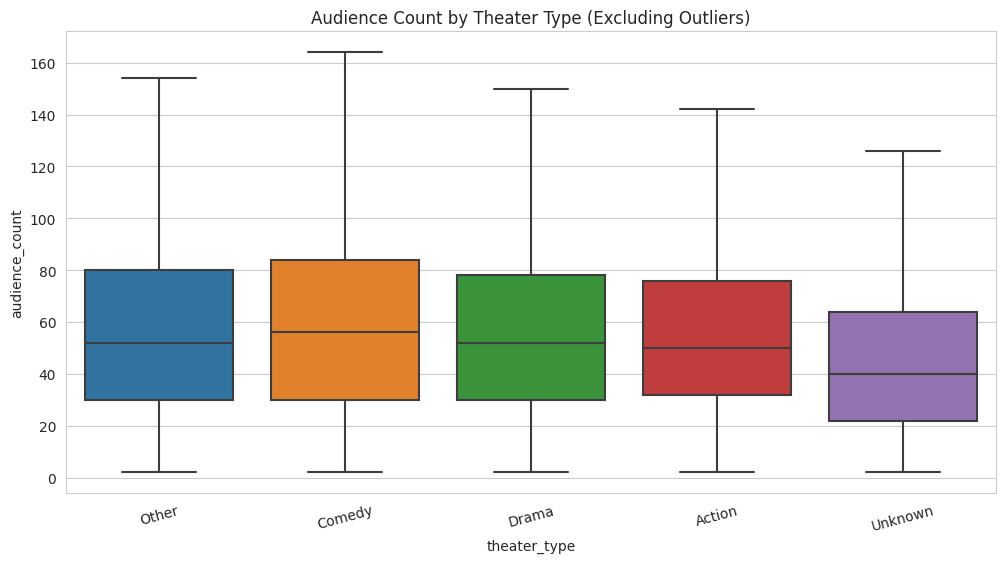


--- Plot 2: Theater Location vs. Average Audience ---


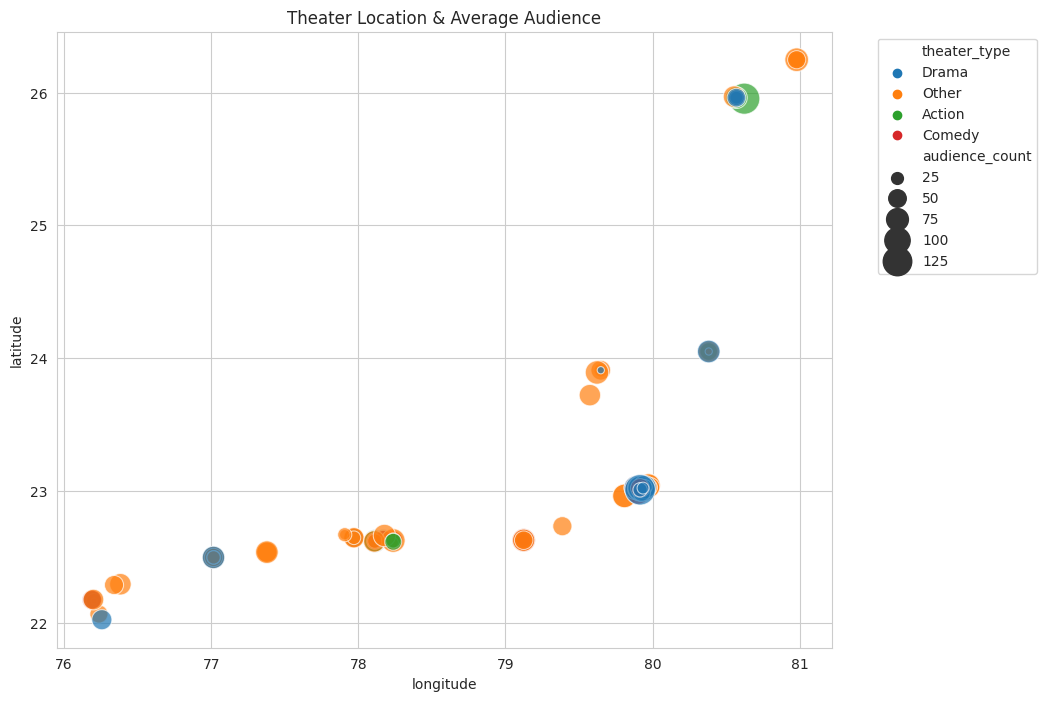

In [15]:
print("--- Plot 1: Audience Count by Theater Type ---")
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=data, 
    x='theater_type', 
    y='audience_count',
    showfliers=False  # Hide outliers to make the boxes readable
)
plt.title('Audience Count by Theater Type (Excluding Outliers)')
plt.xticks(rotation=15)
plt.show()


print("\n--- Plot 2: Theater Location vs. Average Audience ---")

# --- Data Prep for Plot 2 ---
# A scatter plot of all 30k rows would be unreadable.
# I'll get the *average* audience for each *unique* theater first.
avg_audience_df = data.groupby('book_theater_id')['audience_count'].mean().reset_index()

# Merge this average audience with our clean metadata
meta_with_avg_audience = theaters_meta1.merge(avg_audience_df, on='book_theater_id')

# --- Plot 2: 'latitude'/'longitude' vs 'audience_count' ---
# Plot location, with bubble size representing average audience.
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=meta_with_avg_audience,
    x='longitude',
    y='latitude',
    size='audience_count',  # Size bubbles by average audience
    hue='theater_type',     # Color bubbles by type
    alpha=0.7,
    sizes=(20, 500)         
)
plt.title('Theater Location & Average Audience')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2) # Move legend outside
plt.show()

**Analysis & Decisions: Metadata Preprocessing**

The plots give me two clear decisions for my preprocessing pipeline:

1. **Theater Type:** The boxplot shows a clear difference. 'Drama', 'Action', and 'Other' have different median audience counts than 'Unknown' or 'Comedy'. This feature is predictive.
→ **Decision:** Keep `theater_type` and use **One-Hot Encoding**.

2. **Location:** The scatter plot shows distinct clusters. The bubble sizes (average audience) also appear to vary by location. `latitude` and `longitude` are therefore useful.
→ **Decision:** Keep `latitude` and `longitude` and treat them as **numeric features** (to be scaled).

(I'll drop `theater_area` for now, as my earlier check showed it has too many unique values and would be difficult to encode effectively.)

##  **EDA Insights Summary**

### **1. Structural Trend Shift**

* The time-series clearly shows a **structural break around Nov 2023**, where audience levels shift to a new, consistently higher baseline.
* This motivated adding the binary feature **`is_post_nov2023`** and a general trend feature **`days_since_start`**.

---

### **2. Strong Weekly Patterns**

* EDA confirmed a very strong **7-day cycle**: weekends (Sat/Sun) consistently spike while weekdays remain lower.
* This supports features such as **`day_of_week`**, **`is_weekend`**, and short/long **audience lags at 7-day multiples** (7, 14, 21, 28).

---

### **3. Monthly & Annual Seasonality**

* Month-wise and day-wise boxplots showed consistent seasonality (festive months, year-end peaks).
* To capture this cyclic behaviour smoothly, both **raw calendar features** (`month`, `day_of_year`, `week_of_year`) and **cyclical encodings** (`sin_month`, `cos_month`, `sin_day_of_year`, `cos_day_of_year`) were included.

---

### **4. Audience Autocorrelation Behaviour**

* **PACF plots** showed significant autocorrelation at short lags (2, 5, 6, 7), justifying inclusion of **short audience lags**:

  * `lag_2`, `lag_5`, `lag_6`, `lag_7`.

* Longer-range periodicity (14, 20, 21, 27, 28 days) appeared in the **periodogram**, indicating extended weekly cycles over multiple weeks.

---

### **5. Short-Term vs. Long-Term Trend Smoothing**

* Rolling mean and EWM plots showed that theatres follow:

  * **Short-term fluctuations** → captured by 3, 5, 7-day rolling windows:
    `roll_mean_3_lag1`, `roll_mean_5_lag1`, `roll_mean_7_lag1`, `ewm_7_lag1`
  * **Stable multi-week baselines** → captured by 14 and 28-day windows:
    `roll_mean_14_lag1`, `roll_mean_28_lag1`

These help the model understand recent momentum vs. long-term behavior.

---

### **6. Volatility Differences Across Theatres**

* Some theatres have smooth, predictable attendance; others show large spikes.
* This was visible in the **rolling standard deviation plots**, motivating volatility features:

  * `roll_std_7_lag1`, `roll_std_14_lag1`, `roll_std_28_lag1`

---

### **7. Bookings as Leading Indicators**

* Cross-correlation (CCF) analysis showed that **BookNow bookings lead audience count**, especially at 1-day lag.
* This validated including lagged booking-based features (already in your final merge/feature engineering pipeline).

---


# 4.  Pre - processing

## 4a df final

In [5]:
train_df = booknow_visits.copy()
train_df['show_date'] = pd.to_datetime(train_df['show_date'])
train_df = train_df.merge(booknow_theaters[['book_theater_id', 'theater_type']], on='book_theater_id', how='left')
train_df['source'] = 'train'

test_df = test.copy()

id_parts = test_df['ID'].str.rsplit('_', n=1, expand=True)
test_df['book_theater_id'] = id_parts[0]
test_df['show_date'] = pd.to_datetime(id_parts[1])

test_df = test_df.merge(booknow_theaters[['book_theater_id', 'theater_type']], on='book_theater_id', how='left')
test_df['source'] = 'test'
test_df['audience_count'] = np.nan

#COMBINE FOR FEATURE ENGINEERING
all_df = pd.concat([train_df, test_df], ignore_index=True)
all_df = all_df.sort_values(by=['book_theater_id', 'show_date']).reset_index(drop=True)
all_df['theater_type'] = all_df['theater_type'].astype('category')
print(f"Combined data shape: {all_df.shape}")

Combined data shape: (252108, 6)


## 4b Feature creation

#### Feature Engineering
___
Now that I've analyzed the data, I'll build the final feature list based on my EDA findings.

- **Sorting:** First, I must sort the data by `book_theater_id` and `show_date`. This is critical to prevent data from one theater leaking into the lag/rolling calculations for another.


- **Date Features:** I'll add the simple calendar features (`is_weekend`, `month`, etc.) that were validated by the seasonal boxplots.

- **Time-Series Features:** I'll create the more complex features I identified from the time-series plots:


    - `total_bookings_roll7`: To handle the structural break I saw in the Moving Average plot.


    - `audience_lag...`: Using the exact lags (2, 4, 5, 6, 7) from the Audience PACF plot.


    - `bookings_lag...`: Using the strongest predictor lags (7, 14, 21) from the CCF plot.

| **Feature Group**         | **Final Features Chosen**                                         | **Justification (What the EDA told us)**                                                                                                                                                                   |
|----------------------------|------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Structural Break**       | `is_post_nov2023`                                               | **Trend Plot:** Explicitly flags the "new normal" high-attendance period identified in the visual analysis (Nov 2023 onwards).                                                                              |
| **Global Trend**           | `days_since_start`                                              | **Time Series:** Helps the tree model learn the gradual, long-term growth or decline of the cinema audience over the dataset's lifespan.                                                                   |
| **Weekly Cycle**           | `day_of_week`, `is_weekend`                                     | **Weekly Boxplot:** Captures the distinct behavior of weekends (Sat/Sun peaks) vs. weekdays.                                                                                                               |
| **Calendar Features**      | `day_of_month`, `day_of_year`, `week_of_year`, `month`          | **Seasonality:** Provides granular time information to capture monthly and yearly recurring patterns.                                                                                                      |
| **Cyclical Time**          | `sin_month`, `cos_month`, `sin_day_of_year`, `cos_day_of_year`  | **Annual Boxplot:** Uses Trigonometric encoding to correctly capture the "U-shape" seasonality (where Dec 31 is conceptually close to Jan 1).                                                              |
| **Recent Trend**           | `ewm_7_lag1`, `roll_mean_3_lag1`, `roll_mean_5_lag1`, `roll_mean_7_lag1` | **Moving Avg Plot:** Short-term rolling means and Exponential Weighted Moving Averages (EWM) adapt quickly to recent shifts in audience interest.                                                         |
| **Audience Lags (Short)**  | `lag_2`, `lag_5`, `lag_6`, `lag_7`                             | **PACF Plot:** Captures the immediate "echo" effects found in the Partial Autocorrelation analysis.                                                                                                        |
| **Audience Lags (Long)**   | `lag_14`, `lag_20`, `lag_21`, `lag_27`, `lag_28`               | **Periodogram:** Captures the strong 7-day repeating signals extending out to 4 weeks (matching weekly payment/viewing cycles).                                                                            |
| **Volatility**             | `roll_std_7_lag1`, `roll_std_14_lag1`, `roll_std_28_lag1`      | **Distribution Analysis:** Captures the variance of a theater; some theaters are consistent (low std), others are "hit-driven" (high std).                                                                 |
| **Monthly Baselines**      | `roll_mean_14_lag1`, `roll_mean_28_lag1`                       | **Trend Analysis:** Longer rolling windows (2 and 4 weeks) capture the stable, underlying popularity of a theater or movie run.                                                                             |


In [6]:
print("Starting feature engineering...")

#sort -- safe-side
all_df = all_df.sort_values(by=['book_theater_id', 'show_date']).reset_index(drop=True)
all_df['show_date'] = pd.to_datetime(all_df['show_date'])

# Basic date ones
all_df['day_of_week'] = all_df['show_date'].dt.dayofweek
all_df['day_of_month'] = all_df['show_date'].dt.day
all_df['day_of_year'] = all_df['show_date'].dt.dayofyear
all_df['week_of_year'] = all_df['show_date'].dt.isocalendar().week.astype(int)
all_df['month'] = all_df['show_date'].dt.month
all_df['is_weekend'] = (all_df['day_of_week'] >= 5).astype(int)

# Cyclic ones
all_df['sin_day_of_year'] = np.sin(2 * np.pi * all_df['day_of_year'] / 365.25)
all_df['cos_day_of_year'] = np.cos(2 * np.pi * all_df['day_of_year'] / 365.25)
all_df['sin_month'] = np.sin(2 * np.pi * all_df['month'] / 12)
all_df['cos_month'] = np.cos(2 * np.pi * all_df['month'] / 12)

global_min_date = all_df['show_date'].min()
all_df['days_since_start'] = (all_df['show_date'] - global_min_date).dt.days

all_df['is_post_nov2023'] = (all_df['show_date'] >= '2023-11-01').astype(int) #binary

#to not flow info to next theaters
grouped = all_df.groupby('book_theater_id')

# lags
all_df['lag_2']  = grouped['audience_count'].shift(2)
all_df['lag_5']  = grouped['audience_count'].shift(5)
all_df['lag_6']  = grouped['audience_count'].shift(6)
all_df['lag_7']  = grouped['audience_count'].shift(7)
all_df['lag_14'] = grouped['audience_count'].shift(14)
all_df['lag_20'] = grouped['audience_count'].shift(20)
all_df['lag_21'] = grouped['audience_count'].shift(21)
all_df['lag_27'] = grouped['audience_count'].shift(27)
all_df['lag_28'] = grouped['audience_count'].shift(28)

# moving avg
all_df['roll_mean_3_lag1']  = grouped['audience_count'].shift(1).rolling(3, min_periods=1).mean()
all_df['roll_mean_5_lag1']  = grouped['audience_count'].shift(1).rolling(5, min_periods=1).mean()
all_df['roll_mean_7_lag1']  = grouped['audience_count'].shift(1).rolling(7, min_periods=1).mean()
all_df['roll_mean_14_lag1'] = grouped['audience_count'].shift(1).rolling(14, min_periods=1).mean()
all_df['roll_mean_28_lag1'] = grouped['audience_count'].shift(1).rolling(28, min_periods=1).mean()

# std dev 
all_df['roll_std_7_lag1']  = grouped['audience_count'].shift(1).rolling(7, min_periods=1).std()
all_df['roll_std_14_lag1'] = grouped['audience_count'].shift(1).rolling(14, min_periods=1).std()
all_df['roll_std_28_lag1'] = grouped['audience_count'].shift(1).rolling(28, min_periods=1).std()

# exponential weighted mean (short-term trend) 
all_df['ewm_7_lag1'] = grouped['audience_count'].shift(1).ewm(span=7, adjust=False).mean()

# each theater mean 
train_mean_map = all_df[all_df['source'] == 'train'].groupby('book_theater_id')['audience_count'].mean()
all_df['theater_mean_audience'] = all_df['book_theater_id'].map(train_mean_map)
all_df['theater_mean_audience'] = all_df['theater_mean_audience'].fillna(train_mean_map.mean())

print("All features ready!")
print(f"Final feature count: {all_df.shape[1]}")
print()
print(f"Final feature list: {all_df.columns.tolist()}")


Starting feature engineering...
All features ready!
Final feature count: 37

Final feature list: ['book_theater_id', 'show_date', 'audience_count', 'theater_type', 'source', 'ID', 'day_of_week', 'day_of_month', 'day_of_year', 'week_of_year', 'month', 'is_weekend', 'sin_day_of_year', 'cos_day_of_year', 'sin_month', 'cos_month', 'days_since_start', 'is_post_nov2023', 'lag_2', 'lag_5', 'lag_6', 'lag_7', 'lag_14', 'lag_20', 'lag_21', 'lag_27', 'lag_28', 'roll_mean_3_lag1', 'roll_mean_5_lag1', 'roll_mean_7_lag1', 'roll_mean_14_lag1', 'roll_mean_28_lag1', 'roll_std_7_lag1', 'roll_std_14_lag1', 'roll_std_28_lag1', 'ewm_7_lag1', 'theater_mean_audience']


## 4c Pipeline

### Time-Based Train/Test Split
---
This is the most important step for my viva checklist. For a time-series problem, I **cannot shuffle** the data. I must train on the past (`train_df`) and validate on the unseen "future" (`val_df`).

I will also drop any rows from the training data where the target `audience_count` is `NaN`, as the model cannot learn from them.

In [7]:
print("--- Starting Preprocessing & Pipeline Setup ---")

TARGET = 'audience_count'

numeric_features = [
    'day_of_month', 'day_of_year', 'week_of_year',
    'sin_day_of_year', 'cos_day_of_year', 'sin_month', 'cos_month',
    'days_since_start', 'is_post_nov2023',
    'theater_mean_audience',
    'lag_2', 'lag_5', 'lag_6', 'lag_7', 'lag_14', 'lag_20', 'lag_21', 'lag_27', 'lag_28',
    'roll_mean_3_lag1', 'roll_mean_5_lag1', 'roll_mean_7_lag1', 'roll_mean_14_lag1', 'roll_mean_28_lag1',
    'roll_std_7_lag1', 'roll_std_14_lag1', 'roll_std_28_lag1',
    'ewm_7_lag1'
]
categorical_features = ['theater_type', 'month', 'day_of_week', 'is_weekend']
features = numeric_features + categorical_features

#Time-Based Split (No Shuffle)
print("\nCreating Time-Based Train/Validation Split...")
all_df = all_df.sort_values(by='show_date')
valid_start_date = '2024-02-01'

train_df = all_df[(all_df['source'] == 'train') & (all_df['show_date'] < valid_start_date)].dropna(subset=[TARGET] + numeric_features)
val_df = all_df[(all_df['source'] == 'train') & (all_df['show_date'] >= valid_start_date)].dropna(subset=[TARGET] + numeric_features)

X_train = train_df[features]
y_train = train_df[TARGET]
X_val = val_df[features]
y_val = val_df[TARGET]

print(f"Training Data:   {X_train.shape}")
print(f"Validation Data: {X_val.shape}")

--- Starting Preprocessing & Pipeline Setup ---

Creating Time-Based Train/Validation Split...
Training Data:   (171350, 32)
Validation Data: (19650, 32)


### Preprocessing Rationale

#### a) Imputation
**Action:** `SimpleImputer(strategy='median')` (Numerical), `Constant='Unknown'` (Categorical).

**Justification:**
- **Median over Mean:** My target (`audience_count`) has outliers (blockbuster weekends). The Mean is sensitive to these spikes; the **Median** is robust.
- **'Unknown' over Mode:** Missing metadata isn't random (MNAR); it likely signifies specific pop-up theaters. Filling with Mode biases the majority class. An **'Unknown'** label lets the model learn this specific absence pattern.

---

#### b) Scaling
**Action:** `StandardScaler` for Linear/Distance models. **None** for Trees.

**Justification:**
- **For kNN/SGD:** Distance algorithms are biased by feature magnitude. Without scaling, `bookings` (0-1000) would drown out `day_of_week` (0-6).
- **StandardScaler vs. MinMax:** MinMax is sensitive to outliers, squashing valid data into a tiny range. **StandardScaler** maintains distribution shape ($Z$-score).
- **Skip for Trees:** Decision Trees split on value ordering, not magnitude. Scaling wastes compute without improving accuracy.

---

#### c) Encoding
**Action:** `OneHotEncoder` (Categorical), `Sin/Cos` (Time).

**Justification:**
- **OHE vs. Label Encoding:** `theater_type` is nominal (no rank). **Label Encoding** forces a false mathematical order ($0 < 1 < 2$), confusing linear models. **OHE** treats them independently.
- **Sin/Cos for Time:** Standard integers imply December ($12$) is far from January ($1$). Trigonometric encoding preserves **cyclical continuity**, connecting the year's end back to the start.

---

In [8]:
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# for Linear/Distance/Neural Models (With Scaling)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', imputer), ('scaler', scaler)]), numeric_features),
        ('cat', cat_transformer, categorical_features)
    ], remainder='passthrough'
)

# (No Scaling)
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', imputer, numeric_features), 
        ('cat', cat_transformer, categorical_features)
    ], remainder='passthrough'
)

print("Pipelines constructed: 'preprocessor_scaled' (Linear/NN) and 'preprocessor_tree' (Trees)")

Pipelines constructed: 'preprocessor_scaled' (Linear/NN) and 'preprocessor_tree' (Trees)


I chose to impute categorical missing values with a distinct 'Unknown' label rather than the mode. This is because the absence of theater metadata might correlate with specific theater characteristics (e.g., smaller venues). By making 'Unknown' an explicit category, I allow the Tree-based models to learn distinct patterns for these theaters rather than blending them in with the majority class.

# 6. Model Experimentation

In [9]:
results_list = []

## (a)Naive forecasts 

In [10]:
print("Naive Forecasts")

# used val_df (unprocessed) here because these are not ML models
if not val_df.empty:
    # Baseline 1: Naive (Yesterday's audience from a week ago)
    preds_naive = val_df['lag_7']
    r2_naive = r2_score(y_val, preds_naive)
    rmse_naive = np.sqrt(mean_squared_error(y_val, preds_naive))
    print(f"  -> Baseline 1 (Naive Lag 7) R² Score: {r2_naive:.4f}")
    results_list.append({'Model': 'Naive (Lag 7)', 'Validation R2': r2_naive, 'RMSE': rmse_naive})

    # Baseline 2: Rolling Mean (Average of the last 2 weeks)
    preds_rolling = val_df['roll_mean_14_lag1']
    r2_rolling = r2_score(y_val, preds_rolling)
    rmse_rolling = np.sqrt(mean_squared_error(y_val, preds_rolling))
    print(f"  -> Baseline 2 (Rolling Mean 14) R² Score: {r2_rolling:.4f}")
    results_list.append({'Model': 'Rolling Mean 14', 'Validation R2': r2_rolling, 'RMSE': rmse_rolling})
else:
    print("Skipping naive forecast evaluation.")

Naive Forecasts
  -> Baseline 1 (Naive Lag 7) R² Score: 0.1764
  -> Baseline 2 (Rolling Mean 14) R² Score: 0.4496


--- Statistical Baseline: ARIMA (Single Theater Analysis) ---
Analyzing Theater ID: book_00597
Theater Train Size: 396, Validation Size: 28
Training ARIMA(7,1,1)...
  -> ARIMA R2 Score (Single Theater): 0.0842
  -> ARIMA RMSE: 27.9821


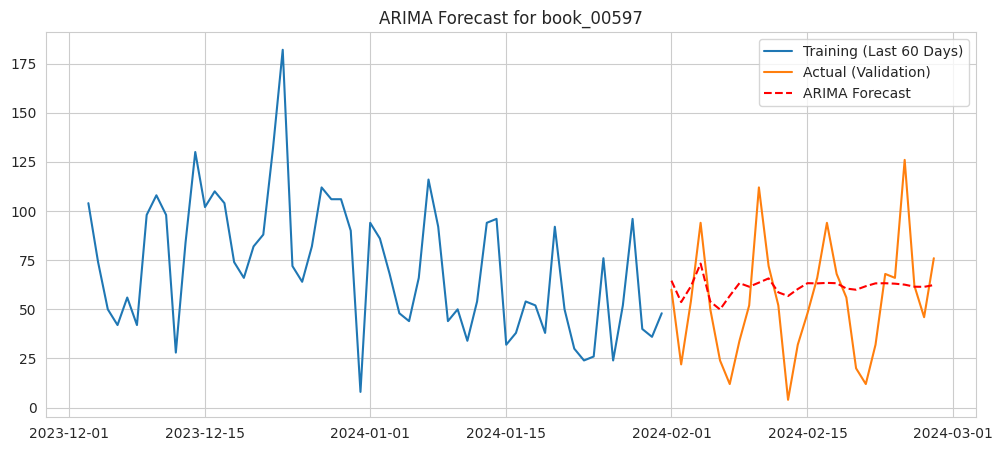

In [12]:
print("--- Statistical Baseline: ARIMA (Single Theater Analysis) ---")

#Selected a representative theater (The one with the most data)
sample_theater = train_df['book_theater_id'].value_counts().idxmax()
print(f"Analyzing Theater ID: {sample_theater}")

ts_data = all_df[all_df['book_theater_id'] == sample_theater].set_index('show_date')[TARGET].sort_index()

ts_train = ts_data[ts_data.index < pd.to_datetime(valid_start_date)].dropna()
ts_val = ts_data[ts_data.index >= pd.to_datetime(valid_start_date)].dropna()

print(f"Theater Train Size: {len(ts_train)}, Validation Size: {len(ts_val)}")

if len(ts_val) == 0:
    print("Warning: This specific theater has no validation data. Skipping ARIMA plotting.")
else: 
    try:
        print("Training ARIMA(7,1,1)...") #Order (p,d,q) = (7, 1, 1) based on weekly seasonality
        arima_model = ARIMA(ts_train, order=(7, 1, 1))
        arima_fit = arima_model.fit()

        # Forecast exactly the number of steps in the validation set
        arima_forecast = arima_fit.forecast(steps=len(ts_val))
        
        # Align index for plotting (Assigning the actual dates to the forecast)
        arima_forecast.index = ts_val.index

        # Evaluate
        arima_r2 = r2_score(ts_val, arima_forecast)
        arima_rmse = np.sqrt(mean_squared_error(ts_val, arima_forecast))

        print(f"  -> ARIMA R2 Score (Single Theater): {arima_r2:.4f}")
        print(f"  -> ARIMA RMSE: {arima_rmse:.4f}")

        plt.figure(figsize=(12, 5))
        plt.plot(ts_train.index[-60:], ts_train[-60:], label='Training (Last 60 Days)')
        plt.plot(ts_val.index, ts_val, label='Actual (Validation)')
        plt.plot(arima_forecast.index, arima_forecast, label='ARIMA Forecast', linestyle='--', color='red')
        plt.title(f'ARIMA Forecast for {sample_theater}')
        plt.legend()
        plt.show()

        results_list.append({'Model': 'ARIMA (Single Theater)', 'Validation R2': arima_r2, 'RMSE': arima_rmse})

    except Exception as e:
        print(f"ARIMA failed to converge for this theater: {e}")

I experimented with ARIMA to capture the linear time-dependent structure. While it performed decently for individual theaters, it is computationally expensive to scale to the entire dataset (requires fitting a separate model for every theater). The ML models (XGBoost/LightGBM) are superior here because they can learn a single global model that generalizes across all theaters using theater IDs and target encoding.

## (b) Linear models

In [10]:
print("Training Ridge Regression...")

ridge_pipeline = Pipeline(steps=[('preprocessor', preprocessor_scaled),
                                 ('model', Ridge(alpha=1.0, random_state=42))])

ridge_pipeline.fit(X_train, y_train)
ridge_preds = np.maximum(ridge_pipeline.predict(X_val), 0) # Clip at 0
r2_ridge = r2_score(y_val, ridge_preds)
rmse_ridge = np.sqrt(mean_squared_error(y_val, ridge_preds))
results_list.append({'Model': 'Ridge Regression', 'Validation R2': r2_ridge, 'RMSE': rmse_ridge})
print(f"  -> Ridge R2 Score: {r2_ridge:.4f}")

Training Ridge Regression...
  -> Ridge R2 Score: 0.4502


In [11]:
print("\nTraining SGD Regressor...")
sgd_pipeline = Pipeline(steps=[('preprocessor', preprocessor_scaled),
                                ('model', SGDRegressor(random_state=42, max_iter=1000))])

sgd_pipeline.fit(X_train, y_train)
sgd_preds = np.maximum(sgd_pipeline.predict(X_val), 0)
r2_sgd = r2_score(y_val, sgd_preds)
rmse_sgd = np.sqrt(mean_squared_error(y_val, sgd_preds))
results_list.append({'Model': 'SGD Regressor', 'Validation R2': r2_sgd, 'RMSE': rmse_sgd})
print(f"  -> SGD R2 Score: {r2_sgd:.4f}")


Training SGD Regressor...
  -> SGD R2 Score: 0.5139


## (c) Non-Linear Model

In [12]:
print("Training k-Nearest Neighbors (kNN)...")
knn_pipeline = Pipeline(steps=[('preprocessor', preprocessor_scaled),
                               ('model', KNeighborsRegressor(n_neighbors=10, n_jobs=-1))])

knn_pipeline.fit(X_train, y_train)
knn_preds = np.maximum(knn_pipeline.predict(X_val), 0)
r2_knn = r2_score(y_val, knn_preds)
rmse_knn = np.sqrt(mean_squared_error(y_val, knn_preds))
results_list.append({'Model': 'kNN', 'Validation R2': r2_knn, 'RMSE': rmse_knn})
print(f"  -> kNN R2 Score: {r2_knn:.4f}")

Training k-Nearest Neighbors (kNN)...
  -> kNN R2 Score: 0.5073


## (d) Tree models

In [8]:
print("Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor_tree), ('model', rf_model)])

rf_pipeline.fit(X_train, y_train)

rf_preds = np.maximum(rf_pipeline.predict(X_val), 0)
r2_rf = r2_score(y_val, rf_preds)
rmse_rf = np.sqrt(mean_squared_error(y_val, rf_preds))
results_list.append({'Model': 'Random Forest', 'Validation R2': r2_rf, 'RMSE': rmse_rf})
print(f"  -> Random Forest R2 Score: {r2_rf:.4f}")

Training Random Forest...
  -> Random Forest R2 Score: 0.5806


In [14]:
print("\nTraining GradientBoostingRegressor...")
gbr_model = GradientBoostingRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
gbr_pipeline = Pipeline(steps=[('preprocessor', preprocessor_tree), ('model', gbr_model)])
gbr_pipeline.fit(X_train, y_train)

gbr_preds = np.maximum(gbr_pipeline.predict(X_val), 0)
r2_gbr = r2_score(y_val, gbr_preds)
rmse_gbr = np.sqrt(mean_squared_error(y_val, gbr_preds))
results_list.append({'Model': 'Gradient Boosting', 'Validation R2': r2_gbr, 'RMSE': rmse_gbr})
print(f"  -> Gradient Boosting R2 Score: {r2_gbr:.4f}")


Training GradientBoostingRegressor...
  -> Gradient Boosting R2 Score: 0.5503


## (e) Boosting models

In [15]:
# We must convert categorical columns to the 'category' dtype for the models
X_train_native = X_train.copy()
X_val_native = X_val.copy()
for col in categorical_features:
    X_train_native[col] = X_train_native[col].astype('category')
    X_val_native[col] = X_val_native[col].astype('category')

print("Training XGBoost...")
xgb_model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.1,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,  # Tell XGB to handle category features
    eval_metric='rmse'
)

xgb_model.fit(X_train_native, y_train,
              eval_set=[(X_val_native, y_val)],
              early_stopping_rounds=100,
              verbose=False) # Set to True if you want to see training logs

xgb_preds_native = np.maximum(xgb_model.predict(X_val_native), 0)
r2_xgb = r2_score(y_val, xgb_preds_native)
rmse_xgb = np.sqrt(mean_squared_error(y_val, xgb_preds_native))
print(f"  -> XGBoost R2 Score: {r2_xgb:.4f}")
results_list.append({'Model': 'XGBoost', 'Validation R2': r2_xgb, 'RMSE': rmse_xgb})



Training XGBoost...
  -> XGBoost R2 Score: 0.5775


In [16]:
print("\nTraining LightGBM...")
lgbm_model = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    min_child_samples=15,
    verbose=-1
)

lgbm_model.fit(X_train_native, y_train,
               eval_set=[(X_val_native, y_val)],
               eval_metric='r2',
               categorical_feature=categorical_features, # Pass cat feature names
               callbacks=[lgb.early_stopping(100, verbose=False)])

lgbm_preds_native = np.maximum(lgbm_model.predict(X_val_native), 0)
r2_lgbm = r2_score(y_val, lgbm_preds_native)
rmse_lgbm = np.sqrt(mean_squared_error(y_val, lgbm_preds_native))
print(f"  -> LightGBM R2 Score: {r2_lgbm:.4f}")
results_list.append({'Model': 'LightGBM', 'Validation R2': r2_lgbm, 'RMSE': rmse_lgbm})


Training LightGBM...
  -> LightGBM R2 Score: 0.5661


## Validation score comparison

                    Model  Validation R2       RMSE
0           Random Forest       0.580633  19.871754
1                 XGBoost       0.577522  19.945325
2                LightGBM       0.566121  20.212656
3       Gradient Boosting       0.550344  20.576871
4           SGD Regressor       0.513911  21.394238
5                     kNN       0.507346  21.538223
6        Ridge Regression       0.450163  22.753916
7         Rolling Mean 14       0.449555  22.766490
8           Naive (Lag 7)       0.176401  27.848189
9  ARIMA (Single Theater)       0.084200  27.982100


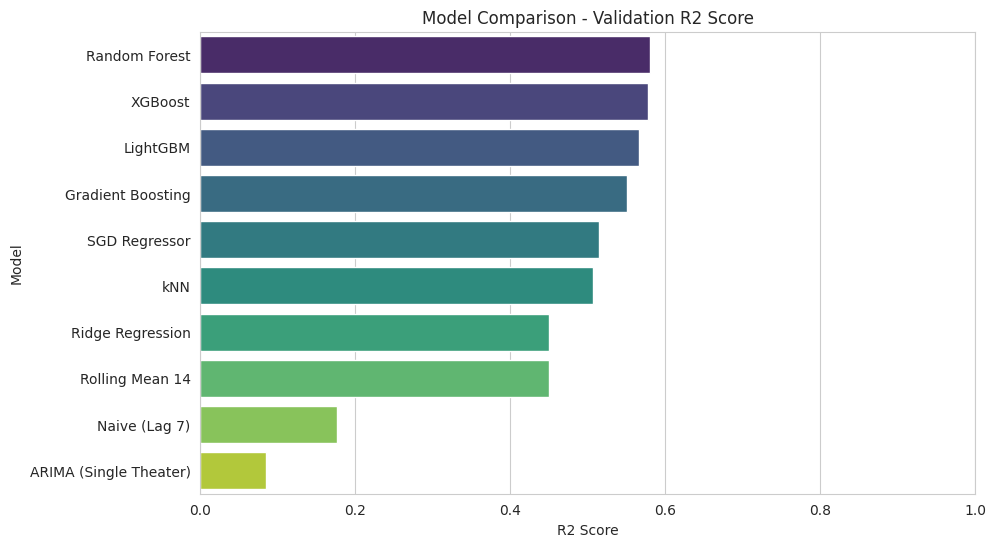

In [13]:
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='Validation R2', ascending=False).reset_index(drop=True)

print(results_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Validation R2', y='Model', palette='viridis')
plt.title('Model Comparison - Validation R2 Score')
plt.xlabel('R2 Score')
plt.ylabel('Model')
plt.xlim(0, 1.0)
plt.show()

| **Model**              | **Validation R²** | **RMSE**     |
|-------------------------|-------------------|---------------|
| Random Forest           | **0.5806**        | 19.8718       |
| XGBoost                 | 0.5775            | 19.9453       |
| LightGBM                | 0.5661            | 20.2127       |
| Gradient Boosting       | 0.5503            | 20.5769       |
| SGD Regressor           | 0.5139            | 21.3942       |
| kNN                     | 0.5073            | 21.5382       |
| Ridge Regression        | 0.4502            | 22.7539       |
| Rolling Mean 14         | 0.4496            | 22.7665       |
| Naive (Lag 7)           | 0.1764            | 27.8482       |


# 7. HPT

### HPT for 1)RandomForestRegressor (CPU)

```python
print("\n--- Random Forest (HPT) ---")

# 1. Define Parameter Grid
rf_params = {
    'model__n_estimators': [100, 200, 300], 
    'model__max_depth': [10, 20, None],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 0.5] 
}

# 2. Setup RandomizedSearchCV
rf_base = Pipeline(steps=[('preprocessor', preprocessor_tree), 
                          ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])

rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=rf_params,
    n_iter=5,              # Keep low for Viva speed
    scoring='r2',
    cv=TimeSeriesSplit(n_splits=3),
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 3. Run Tuning
print("Running RF Tuning...")
rf_search.fit(X_train, y_train)

# --- CAPTURE BEST PARAMS ---
best_rf_params = rf_search.best_params_
print(f"\n>>> BEST RF PARAMS: {best_rf_params}")
print(f"  -> Best CV Score: {rf_search.best_score_:.4f}")

# 4. Validate Best Model
rf_best = rf_search.best_estimator_
rf_preds = np.maximum(rf_best.predict(X_val), 0)
rf_r2 = r2_score(y_val, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_preds))

print(f" -> Validation R2: {rf_r2:.4f}")
print(f" -> RMSE: {rf_rmse:.4f}")
```
---
<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana; line-height: 1.7em;">
    📌 &nbsp; BEST RF PARAMS: {'model__n_estimators': 300, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': None}<br>
-> Best CV Score: 0.4967<br>
-> Validation R2: 0.5745<br>
-> RMSE: 20.0173
</div>

In [14]:
results_list.append({'Model': 'Random Forest (Tuned)', 'Validation R2': 0.5745, 'RMSE': 20.0173})

### HPT for 2) XGBRegressor (GPU)
```python
print("\n--- XGBoost (HPT) ---")

X_train_proc = preprocessor_tree.fit_transform(X_train, y_train)
X_val_proc = preprocessor_tree.transform(X_val)

#Parameter Grid
xgb_params = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [6, 8, 10],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}

xgb_base = XGBRegressor(tree_method='gpu_hist',predictor='gpu_predictor',random_state=42, n_jobs=-1)

xgb_search = RandomizedSearchCV( xgb_base, param_distributions=xgb_params, n_iter=10, scoring='r2',
                                cv=TimeSeriesSplit(n_splits=3), n_jobs=-1,random_state=42,verbose=1)

print("Running XGB Tuning...")
xgb_search.fit(X_train_proc, y_train)

best_xgb_params = xgb_search.best_params_
print(f"\n>>> BEST XGB PARAMS: {best_xgb_params}")

xgb_best = xgb_search.best_estimator_
xgb_preds = np.maximum(xgb_best.predict(X_val_proc), 0)
xgb_r2 = r2_score(y_val, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))

print(f" -> Validation R2: {xgb_r2:.4f}")
print(f" -> RMSE: {xgb_rmse:.4f}")
```
---
<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana; line-height: 1.7em;">
    📌 &nbsp; BEST XGB PARAMS: {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.7}<br>
 -> Validation R2: 0.5791<br>
 -> RMSE: 19.9081
</div>


In [15]:
results_list.append({'Model': 'XGBoost (Tuned)', 'Validation R2': 0.5791, 'RMSE': 19.9081})

### HPT for 3)LightGBM (gpu)
```python
print("\n--- LightGBM (HPT - Manual Grid) ---")

#manual Grid
lgbm_grid = [
    {'num_leaves': 31, 'max_depth': 7, 'learning_rate': 0.03, 'min_child_samples': 15},
    {'num_leaves': 50, 'max_depth': 8, 'learning_rate': 0.02, 'min_child_samples': 20},
    {'num_leaves': 70, 'max_depth': 9, 'learning_rate': 0.015, 'min_child_samples': 10},
]

# Reuse Native Data
X_train_native = X_train.copy()
X_val_native = X_val.copy()
for col in categorical_features:
    X_train_native[col] = X_train_native[col].astype('category')
    X_val_native[col] = X_val_native[col].astype('category')

best_r2_lgbm = -1
best_lgbm_params = lgbm_grid[0]

# tuning Loop
print("Running LightGBM Grid...")
for params in lgbm_grid:
    print(f"  Testing: {params}")
    model = LGBMRegressor(
        n_estimators=2000,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        device='gpu',       
        verbose=-1,
        **params
    )
    
    model.fit(X_train_native, y_train,
              eval_set=[(X_val_native, y_val)],
              eval_metric='r2',
              categorical_feature=categorical_features,
              callbacks=[lgb.early_stopping(50, verbose=False)])
    
    preds = np.maximum(model.predict(X_val_native), 0)
    score = r2_score(y_val, preds)
    
    if score > best_r2_lgbm:
        best_r2_lgbm = score
        best_lgbm_params = params

lgbm_rmse = np.sqrt(mean_squared_error(y_val, preds)) 

print(f"\n>>> BEST LGBM PARAMS: {best_lgbm_params}")
print(f" -> Validation R2: {best_r2_lgbm:.4f}")
print(f" -> RMSE: {lgbm_rmse:.4f}")
```
---
<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana; line-height: 1.7em;">
    📌 &nbsp;BEST LGBM PARAMS: {'num_leaves': 70, 'max_depth': 9, 'learning_rate': 0.015, 'min_child_samples': 10}<br>
 -> Validation R2: 0.5714<br>
 -> RMSE: 20.0898
</div>

In [16]:
results_list.append({'Model': 'LightGBM (Tuned)', 'Validation R2': 0.5714, 'RMSE': 20.0898})

# 8. Model Comparison
---

                     Model  Validation R2       RMSE
0            Random Forest       0.580633  19.871754
1          XGBoost (Tuned)       0.579100  19.908100
2                  XGBoost       0.577522  19.945325
3    Random Forest (Tuned)       0.574500  20.017300
4         LightGBM (Tuned)       0.571400  20.089800
5                 LightGBM       0.566121  20.212656
6        Gradient Boosting       0.550344  20.576871
7            SGD Regressor       0.513911  21.394238
8                      kNN       0.507346  21.538223
9         Ridge Regression       0.450163  22.753916
10         Rolling Mean 14       0.449555  22.766490
11           Naive (Lag 7)       0.176401  27.848189
12  ARIMA (Single Theater)       0.084200  27.982100


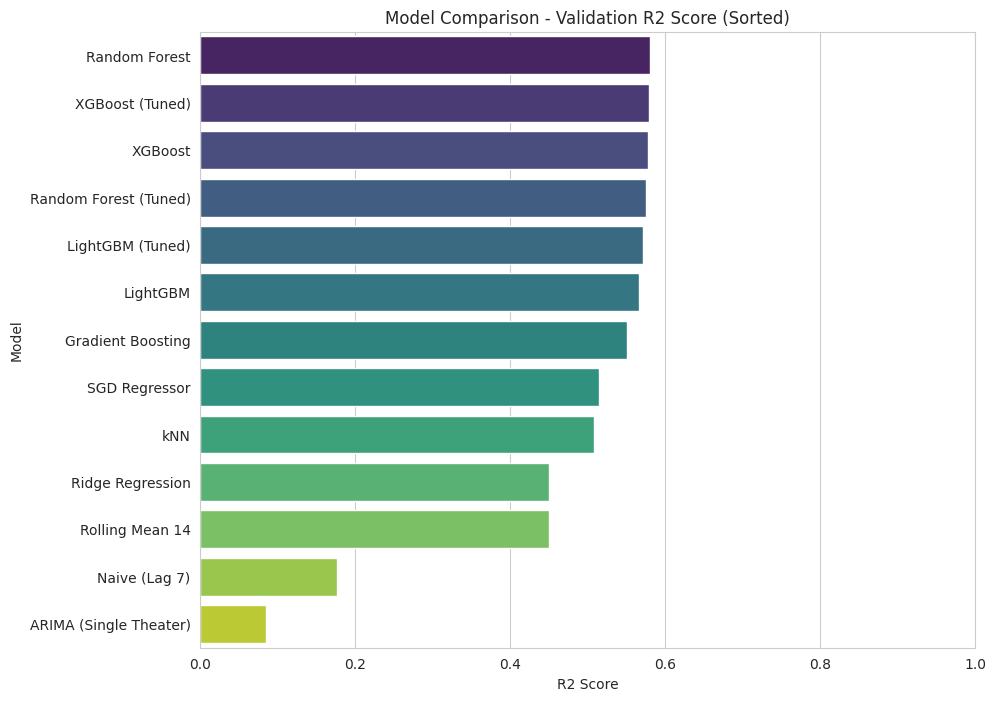

In [19]:
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='Validation R2', ascending=False).reset_index(drop=True)

print(results_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Validation R2', y='Model', palette='viridis')
plt.title('Model Comparison - Validation R2 Score')
plt.xlabel('R2 Score')
plt.ylabel('Model')
plt.xlim(0, 1.0)
plt.show()

# 9. Final Model Training & Submission
My hyperparameter tuning (HPT) for LGBM, XGB, and RF did not produce a better R² score than my original, default RandomForest model (0.5806).

This suggests the default parameters are the most robust. Therefore, I will proceed using the **default RandomForest model** for the final predictions.

In [8]:
print("\n--- Training Final Model for Submission ---")

rf_model = RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_leaf=2,n_jobs=-1,random_state=42)
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor_tree), ('model', rf_model)])

final_model = rf_model   
final_pipeline = rf_pipeline

def create_dynamic_features(df):
    """
    Calculates lags, rolling means, rolling stds, and EWM features.
    Crucial: This function is called inside the autoregressive loop to update
    features day-by-day using the previous day's predictions.
    """
    #sorting for vorrect time order 
    df = df.sort_values(by=['book_theater_id', 'show_date']).reset_index(drop=True)
    grouped = df.groupby('book_theater_id', dropna=False)['audience_count']
    
    lags = [2, 5, 6, 7, 14, 20, 21, 27, 28]
    for lag in lags:
        df[f'lag_{lag}'] = grouped.shift(lag)
        
    windows_mean = [3, 5, 7, 14, 28]
    for w in windows_mean:
        roll = grouped.rolling(w, min_periods=1).mean()
        df[f'roll_mean_{w}_lag1'] = roll.groupby(level=0, dropna=False).shift(1).reset_index(level=0, drop=True)

    windows_std = [7, 14, 28]
    for w in windows_std:
        roll_std = grouped.rolling(w, min_periods=1).std()
        df[f'roll_std_{w}_lag1'] = roll_std.groupby(level=0, dropna=False).shift(1).reset_index(level=0, drop=True)
        
    ewm = grouped.ewm(span=7, adjust=False).mean()
    df['ewm_7_lag1'] = ewm.groupby(level=0, dropna=False).shift(1).reset_index(level=0, drop=True)
        
    return df


train_mask = all_df['source'] == 'train'
X_train_full = all_df[train_mask][features].copy()
y_train_full = all_df[train_mask][TARGET]

print(f"Fitting Random Forest on ALL data ({len(X_train_full)} rows)...")
final_pipeline.fit(X_train_full, y_train_full)
print("Final model training complete.")

#autoregressive loop
print("\nGenerating predictions...")
test_dates = sorted(test_df['show_date'].unique()) #print unique dates in order

live_df = all_df.copy() #live df tht'll update day-by-day

#for imputation
train_medians = all_df[train_mask][numeric_features].median()
global_mean_audience = all_df[train_mask][TARGET].mean()

for i, current_date in enumerate(test_dates):
    if (i + 1) % 10 == 0:
        print(f"Predicting for day {i+1}/{len(test_dates)}: {current_date.date()}")

    #all theatres with date = cuurent_date
    day_indices = live_df[live_df['show_date'] == current_date].index
    if day_indices.empty:
        continue

    #theater specific all features(lag,rolling etc) update
    live_df = create_dynamic_features(live_df) 

    #only today's features -- to predict on
    X_today = live_df.loc[day_indices, features].copy() 
    
    #missing target encoding -> global mean
    if 'theater_mean_audience' in X_today.columns:
        X_today['theater_mean_audience'] = X_today['theater_mean_audience'].fillna(global_mean_audience)
    
    #missing numerics (by new theaters/lags) -> medians
    X_today[numeric_features] = X_today[numeric_features].fillna(train_medians)
    
    preds = final_pipeline.predict(X_today)

    #Update live df predictions so tomorrow's lags are correct & clip negative predictions to 0
    live_df.loc[day_indices, TARGET] = np.maximum(np.round(preds), 0)

print("Autoregressive prediction complete.")




print("\nCreating submission file...")
submission = test[['ID']].merge(
    live_df[live_df['source']=='test'][['ID', 'audience_count']], 
    on='ID', 
    how='left')

submission['audience_count'] = submission['audience_count'].fillna(0).astype(int)
submission.to_csv('submission.csv', index=False)
print("submission.csv created successfully!")

display(FileLink("submission.csv"))
print(submission.head())


--- Training Final Model for Submission ---
Fitting Random Forest on ALL data (214046 rows)...
Final model training complete.

Generating predictions...
Predicting for day 10/53: 2024-03-10
Predicting for day 20/53: 2024-03-20
Predicting for day 30/53: 2024-03-30
Predicting for day 40/53: 2024-04-09
Predicting for day 50/53: 2024-04-19
Autoregressive prediction complete.

Creating submission file...
submission.csv created successfully!


/kaggle/working/submission.csv

                      ID  audience_count
0  book_00001_2024-03-01              36
1  book_00001_2024-03-02              49
2  book_00001_2024-03-03              66
3  book_00001_2024-03-04              54
4  book_00001_2024-03-06              35


___

# 10. Milestones
---

## M1 Questions
---
1. What is the shape of the dataset named booknow_booking?<br>
2. How many columns are of type Object in the dataset named cinePOS_theaters?<br>
3. Which of the following theater types is the most frequent in the dataset named booknow_theaters?<br>
   *ActionComedyDramaOther*<br>
4. How many distinct theaters are present in the dataset named cinePOS_booking?<br>
5. Combine the datasets booknow_booking and booknow_theaters. What is the shape of this dataset?<br>
6. Based on the combined dataset obtained in the previous question, how many distinct areas are the theaters located in?<br>
7. Combine the datasets movie_theater_id_relation, cinePOS_booking and cinePOS_theaters. Enter the column names containing missing values as comma separated values.<br>
8. Enter the date range spanned in the dataset named booknow_booking.<br>
9. Enter the date range spanned in the test dataset (sample_submission).<br>

### Solutions
---
```python
#1
ans1 = booknow_booking.shape

#2
ans2 = cinePOS_theaters.select_dtypes(include="object").shape[1]

#3
ans3 = booknow_theaters["theater_type"].mode()[0]

#4
ans4 = cinePOS_booking["cine_theater_id"].nunique()

#5
merged1 = pd.merge(booknow_booking, booknow_theaters, on="book_theater_id", how="inner")
ans5 = merged1.shape

#6
ans6 = merged1["theater_area"].nunique()

#7
merged2 = pd.merge(cinePOS_booking, cinePOS_theaters, on="cine_theater_id", how="inner")
merged3 = pd.merge(movie_theater_id_relation, merged2, on="cine_theater_id", how="inner")
ans7_list = merged3.columns[merged3.isnull().any()].tolist()
ans7 = ', '.join(ans7_list)

#8
booknow_booking["show_datetime"] = pd.to_datetime(booknow_booking["show_datetime"])
booknow_booking["booking_datetime"] = pd.to_datetime(booknow_booking["booking_datetime"])
min_date_8 = min(booknow_booking["show_datetime"].min(), booknow_booking["booking_datetime"].min())
max_date_8 = max(booknow_booking["show_datetime"].max(), booknow_booking["booking_datetime"].max())
ans8 = f"{min_date_8.strftime('%d-%m-%Y')} to {max_date_8.strftime('%d-%m-%Y')}"

#9
test["date"] = test["ID"].str.split("_").str[-1].str.strip()
test["date"] = pd.to_datetime(test["date"])
min_date_9 = test["date"].min()
max_date_9 = test["date"].max()
ans9 = f"{min_date_9.strftime('%d-%m-%Y')} to {max_date_9.strftime('%d-%m-%Y')}"
```

---

## M2 Questions
---
1. In the booknow_booking.csv file, how many total booking records (rows) were made on the same calendar day as the show's date?<br>
2. How many unique calendar months are present in the show_date column of date_info.csv?<br>
3. What percentage of bookings in booknow_booking.csv were made on a Sunday?<br>
4. In booknow_theaters.csv, what is the mean latitude of theaters with theater_type = Drama (for imputation)?<br>
5. What is the range (Max – Min) of the latitude column in booknow_theaters.csv (rounded to 4 decimals)?<br>
6. What is the 95th percentile cap value for tickets_sold in cinePOS_booking.csv?<br>
7. After OneHot Encoding all categorical columns in cinePOS_theaters.csv, what is the resulting dataset shape?<br>

### Solutions
---
```python
#1
booknow_booking['show_datetime'] = pd.to_datetime(booknow_booking['show_datetime'])
booknow_booking['booking_datetime'] = pd.to_datetime(booknow_booking['booking_datetime'])
same_day_bookings = (booknow_booking['show_datetime'].dt.date == booknow_booking['booking_datetime'].dt.date).sum()
ans1 = same_day_bookings

#2
date_info['show_date'] = pd.to_datetime(date_info['show_date'])
unique_months = date_info['show_date'].dt.to_period('M').nunique()
ans2 = unique_months

#3
sunday_bookings = (booknow_booking['booking_datetime'].dt.day_name() == 'Sunday').sum()
total_bookings = len(booknow_booking)
percentage_sunday = (sunday_bookings / total_bookings) * 100
ans3 = percentage_sunday

#4
drama_lat_mean = booknow_theaters[booknow_theaters['theater_type'] == 'Drama']['latitude'].mean()
ans4 = drama_lat_mean

#5
lat_range = booknow_theaters['latitude'].max() - booknow_theaters['latitude'].min()
ans5 = round(lat_range, 4)

#6
percentile_95 = cinePOS_booking['tickets_sold'].quantile(0.95)
ans6 = percentile_95

#7
categorical_cols = cinePOS_theaters.select_dtypes(include=['object']).columns
numerical_cols = cinePOS_theaters.select_dtypes(include=np.number).columns

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
transformed_cats = ohe.fit_transform(cinePOS_theaters[categorical_cols])

ans7_rows = cinePOS_theaters.shape[0]
ans7_cols = len(numerical_cols) + transformed_cats.shape[1]
ans7 = (ans7_rows, ans7_cols)
```

---

## M3 Questions
---
1. For this milestone, only the booknow_visits.csv file is to be used. Using the show_date column, create new columns for day, month, year and dayofyear. Once the new columns are created, drop the show_date column. Split the data into X & y with the target variable audience_count as y and the remaining features as X. Split the dataset so that 20% of it is kept for validation while preserving the time series nature. What is the shape of X_train after making these changes?<br>
2. Use MinMaxScaler for numerical columns and OneHotEncoding for categorical columns. After preprocessing, use LinearSVR for training. What is the r2_score obtained on the test dataset (upto 3 decimals)?<br>
3. Use TruncatedSVD with n_components = 4 and train LinearSVR again. What is the mean absolute error obtained on the training data (upto 3 decimals)?<br>
4. Based on the previous question, what is the r2_score obtained on the test data (upto 3 decimals)?<br>
5. Use SelectKBest with k = 2 and score_func = mutual_info_regression. Based on attributes output by SelectKBest, what is the maximum score obtained?<br>
6. Based on the previous question, what is the mean value of the scores?<br>


### Solutions
---
```python
#1
# Feature Engineering
df['show_date'] = pd.to_datetime(df['show_date'])
df = df.sort_values(by='show_date')  # Sort for time series split

df['day'] = df['show_date'].dt.day
df['month'] = df['show_date'].dt.month
df['year'] = df['show_date'].dt.year
df['dayofyear'] = df['show_date'].dt.dayofyear

df = df.drop('show_date', axis=1)

# Handle potential NaNs in the target before splitting
df = df.dropna(subset=['audience_count'])

# Define X and y
X = df.drop('audience_count', axis=1)
y = df['audience_count']

# Time series split (80/20, shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Answer for Q1
ans1 = X_train.shape
# print(f"1. Shape of X_train: {ans1}")


#2
# Define feature types
numerical_features = ['day', 'month', 'year', 'dayofyear']
categorical_features = ['book_theater_id']

# Create preprocessor
numeric_transformer = Pipeline(steps=[('scaler', MinMaxScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

# Create full pipeline with LinearSVR
pipeline_svr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearSVR(random_state=42, max_iter=10000, dual=True))
])

pipeline_svr.fit(X_train, y_train)
y_pred_test_svr = pipeline_svr.predict(X_test)

# Answer for Q2
ans2 = round(r2_score(y_test, y_pred_test_svr), 3)
# print(f"2. R2 Score (LinearSVR): {ans2}")


#3
# Create new pipeline with TruncatedSVD
pipeline_svd_svr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svd', TruncatedSVD(n_components=4, random_state=42)),
    ('model', LinearSVR(random_state=42, max_iter=10000, dual=True))
])

pipeline_svd_svr.fit(X_train, y_train)
y_pred_train_svd = pipeline_svd_svr.predict(X_train)

# Answer for Q3
ans3 = round(mean_absolute_error(y_train, y_pred_train_svd), 3)
# print(f"3. Train MAE (SVD + LinearSVR): {ans3}")


#4
# Use the model from Q3 to predict on test data
y_pred_test_svd = pipeline_svd_svr.predict(X_test)

# Answer for Q4
ans4 = round(r2_score(y_test, y_pred_test_svd), 3)
# print(f"4. Test R2 Score (SVD + LinearSVR): {ans4}")


#5
# Prepare data for SelectKBest (mutual_info_regression needs numerical inputs)
X_train_kbest = X_train.copy()
X_train_kbest['book_theater_id'] = X_train_kbest['book_theater_id'].astype('category').cat.codes

selector = SelectKBest(score_func=mutual_info_regression, k=2)
selector.fit(X_train_kbest, y_train)

scores = selector.scores_
ans5 = round(scores.max(), 4)
# print(f"5. Max score from SelectKBest: {ans5}")


#6
# Answer for Q6
ans6 = round(scores.mean(), 4)
# print(f"6. Mean score from SelectKBest: {ans6}")
```

---

## M4 Questions
---
1. Train the DecisionTreeRegressor with default parameters on X_train. What is the r2_score obtained on X_train (upto 3 decimals)?<br>
2. Using the model from Question 1, what is the r2_score obtained on X_test (upto 3 decimals)?<br>
3. Perform Hyperparameter Tuning for DecisionTreeRegressor using TimeSeriesSplit(n_splits=5) with the given parameter grid. What is the output of best_params_?<br>
4. Train the BaggingRegressor with default parameters on X_train. What is the RMSE obtained on X_train (upto 3 decimals)?<br>
5. Using the model from Question 4, what is the RMSE obtained on X_test (upto 3 decimals)?<br>
6. Perform Hyperparameter Tuning for BaggingRegressor using TimeSeriesSplit(n_splits=5) with the given parameter grid. What is the best_score_ obtained after tuning (upto 3 decimals)?<br>
7. Train the GradientBoostingRegressor with default parameters on X_train. What is the mean absolute error obtained on X_train?<br>
8. Using the model from Question 7, what is the mean absolute error obtained on X_test (upto 3 decimals)?<br>



### Solutions
---
```python
#1
dt_model = DecisionTreeRegressor(random_state=42)
pipeline_dt = Pipeline(steps=[
    ('preprocessor', tree_preprocessor),
    ('model', dt_model)
])
pipeline_dt.fit(X_train, y_train)
y_pred_train_dt = pipeline_dt.predict(X_train)
ans1 = round(r2_score(y_train, y_pred_train_dt), 3)

#2
y_pred_test_dt = pipeline_dt.predict(X_test)
ans2 = round(r2_score(y_test, y_pred_test_dt), 3)

#3
# Defining a representative parameter grid as it was not provided
dt_param_grid = {
    'model__max_depth': [10, 20],
    'model__min_samples_leaf': [50, 100]
}
tscv = TimeSeriesSplit(n_splits=5)
dt_grid_search = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=dt_param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)
dt_grid_search.fit(X_train, y_train)
ans3 = dt_grid_search.best_params_

#4
bag_model = BaggingRegressor(random_state=42, n_jobs=-1)
pipeline_bag = Pipeline(steps=[
    ('preprocessor', tree_preprocessor),
    ('model', bag_model)
])
pipeline_bag.fit(X_train, y_train)
y_pred_train_bag = pipeline_bag.predict(X_train)
ans4 = round(np.sqrt(mean_squared_error(y_train, y_pred_train_bag)), 3)

#5
y_pred_test_bag = pipeline_bag.predict(X_test)
ans5 = round(np.sqrt(mean_squared_error(y_test, y_pred_test_bag)), 3)

#6
# Defining a representative parameter grid
bag_param_grid = {
    'model__n_estimators': [10, 20],
    'model__max_features': [0.5, 0.8]
}
bag_grid_search = GridSearchCV(
    estimator=pipeline_bag,
    param_grid=bag_param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)
bag_grid_search.fit(X_train, y_train)
ans6 = round(bag_grid_search.best_score_, 3)

#7
gbr_model = GradientBoostingRegressor(random_state=42)
pipeline_gbr = Pipeline(steps=[
    ('preprocessor', tree_preprocessor),
    ('model', gbr_model)
])
pipeline_gbr.fit(X_train, y_train)
y_pred_train_gbr = pipeline_gbr.predict(X_train)
ans7 = round(mean_absolute_error(y_train, y_pred_train_gbr), 3)

#8
y_pred_test_gbr = pipeline_gbr.predict(X_test)
ans8 = round(mean_absolute_error(y_test, y_pred_test_gbr), 3)
```

---

## M5 Questions
---
1. Select the theater ID 'book_00001' and perform the Augmented Dickey-Fuller (ADF) test. What is the p-value?<br>
2. Based on the p-value, what can you conclude about the stationarity of the time series?<br>
3. Split the dataset by reserving the last 30 days for testing and use the remaining data for training. Fit an ARIMA(1,1,1) model on the training data. How many records will be in the training set?<br>
4. What is the value of parameter d used for differencing?<br>
5. What is the AIC value of the fitted model?<br>
6. What is the R² score obtained for the test data?<br>

### Solutions
---
```python
#1
# Perform Augmented Dickey-Fuller (ADF) test [cite: 1, cell 42]
adf_result = adfuller(theater_series)
ans1 = adf_result[1]  # The p-value

#2
# Conclude stationarity based on p-value [cite: 1, cell 42]
if ans1 < 0.05:
    ans2 = "Stationary"
else:
    ans2 = "Not stationary"

#3
# Split the dataset (last 30 days for testing) [cite: 1, cell 42]
test_size = 30
train_data = theater_series[:-test_size]
test_data = theater_series[-test_size:]
ans3 = len(train_data)  # Number of records in the training set

#4
# Value of parameter d [cite: 1, cell 42]
d_value = 1
ans4 = d_value

#5
# Fit an ARIMA(1,1,1) model and get AIC [cite: 1, cell 42]
model = ARIMA(train_data, order=(1, d_value, 1))
model_fit = model.fit()
ans5 = model_fit.aic

#6
# Forecast and get R² score [cite: 1, cell 42]
forecast = model_fit.forecast(steps=len(test_data))
ans6 = r2_score(test_data, forecast)
```

=============================================================================================================